# LangGraph Supervisor Demo

Acest notebook demonstrează implementarea unui sistem multi-agent folosind biblioteca `langgraph` și modelul `openai/gpt-oss-20b` de la Groq. Sistemul folosește un **supervisor** care coordonează trei agenți specializați (`researcher`, `coder`, `writer`) și decide dinamic care agent trebuie să acționeze la fiecare pas, până când task-ul este complet.

Fluxul de execuție este: `START → supervisor → [researcher | coder | writer] → supervisor → ... → END`

Supervisorul folosește **structured output** (`RouteDecision`) pentru a lua decizii de routing. La fiecare pas, primește lista agenților care au acționat deja (`acted`) și decide cine urmează în ordinea: `researcher → coder → writer → FINISH`. Fiecare agent worker primește un context trimis (primul mesaj + ultimele 2 mesaje) pentru a reduce tokenii consumați, și actualizează câmpul `acted` cu numele său.

Scopul este de a ilustra cum se pot construi sisteme multi-agent flexibile cu routing dinamic, folosind `Command(goto=...)` pentru a gestiona tranzițiile între noduri.

### Instalarea Bibliotecilor Necesare

Această celulă instalează bibliotecile `langgraph` și `langchain-groq`, esențiale pentru construirea grafului de agenți și pentru interacțiunea cu modelele disponibile prin API-ul Groq. Este o etapă pregătitoare obligatorie înainte de a rula codul principal.

In [4]:
!pip install langgraph langchain-groq


### Definirea și Execuția Sistemului Multi-Agent (LangGraph)

Această celulă conține implementarea completă a sistemului multi-agent. Componentele principale sunt:

*   **`GraphState`**: Un `TypedDict` cu două câmpuri — `messages: List[BaseMessage]` (istoricul conversației) și `acted: List[str]` (agenții care au contribuit deja).
*   **`llm`**: Modelul `openai/gpt-oss-20b` inițializat cu `ChatGroq`, cu `temperature=0` pentru răspunsuri deterministe. Cheia API este preluată din Google Colab `userdata`.
*   **`RouteDecision`**: Model Pydantic folosit pentru **structured output** — supervisorul returnează întotdeauna un obiect cu câmpurile `next` (agentul următor sau `FINISH`) și `reason` (justificarea deciziei).
*   **`supervisor_node`**: Nodul central de routing — în loc să trimită tot istoricul, construiește un mesaj scurt cu lista agenților care au acționat deja și decide cine urmează. Routingul urmează ordinea fixă: `researcher → coder → writer → FINISH`.
*   **`make_worker`**: Fabrică de noduri worker — creează funcții generice care invocă LLM-ul cu un context trimis (`messages[:1] + messages[-2:]`) și actualizează `acted` cu propriul nume.
*   **Nodurile worker**:
    *   `researcher_node` — caută și sintetizează informații
    *   `coder_node` — scrie cod Python curat și funcțional
    *   `writer_node` — redactează texte clare pe baza informațiilor primite
*   **Construirea grafului**: Toate nodurile sunt adăugate; punctul de intrare este `supervisor`; routingul dinamic este gestionat exclusiv prin `Command(goto=...)`.
*   **Execuția**: `graph.invoke(...)` pornește cu un `HumanMessage` și `acted=[]`; supervisorul orchestrează agenții până la `FINISH`, iar ultimul mesaj din `result["messages"]` conține răspunsul final.

In [ ]:
from typing import Literal, TypedDict, List
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from pydantic import BaseModel
from google.colab import userdata

# ──────────────────────────────────────────────
# 1. Modelul LLM
# ──────────────────────────────────────────────
# GROQ_API_KEY poate fi luată accesând link-ul https://console.groq.com/keys
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    groq_api_key=userdata.get("GROQ_API_KEY"),
    temperature=0,
)

# ──────────────────────────────────────────────
# 2. Schema de routing (structured output)
# ──────────────────────────────────────────────
class RouteDecision(BaseModel):
    next: Literal["researcher", "coder", "writer", "FINISH"]
    reason: str


llm_router = llm.with_structured_output(RouteDecision)

MEMBERS = ["researcher", "coder", "writer"]
SYSTEM_PROMPT = (
    "Supervisor pt echipa: researcher, coder, writer.\n"
    "Routing în ordine: researcher → coder → writer → FINISH.\n"
    "Mesajul tău va indica cine a acționat deja. Alege următorul."
)


# ──────────────────────────────────────────────
# 3. Starea grafului
# ──────────────────────────────────────────────
class GraphState(TypedDict):
    messages: List[BaseMessage]
    acted: List[str]  # agenți care au contribuit deja


# ──────────────────────────────────────────────
# 4. Nodul supervisor
# ──────────────────────────────────────────────
def supervisor_node(
    state: GraphState,
) -> Command[Literal["researcher", "coder", "writer", END]]:
    acted = state.get("acted", [])
    # Trimite doar un mesaj scurt în loc de tot istoricul
    routing_msg = HumanMessage(content=f"Au acționat deja: {acted or 'nimeni'}. Cine urmează?")
    decision = llm_router.invoke([SystemMessage(content=SYSTEM_PROMPT), routing_msg])

    goto = END if decision.next == "FINISH" else decision.next
    return Command(goto=goto, update={"acted": acted})


# ──────────────────────────────────────────────
# 5. Noduri worker
# ──────────────────────────────────────────────
def make_worker(name: str, description: str):
    def worker_node(state: GraphState) -> Command[Literal["supervisor"]]:
        # Workerul primește doar primul mesaj (cererea originală) + ultimul context relevant
        context = state["messages"][:1] + state["messages"][-2:]
        result = llm.invoke(
            [SystemMessage(content=f"Ești {name}. {description}")]
            + context
        )
        acted = state.get("acted", []) + [name]
        return Command(
            goto="supervisor",
            update={"messages": state["messages"] + [result], "acted": acted},
        )

    worker_node.__name__ = f"{name}_node"
    return worker_node


researcher_node = make_worker(
    "researcher",
    "Caută și sintetizează informații. Răspunde concis cu datele găsite.",
)
coder_node = make_worker(
    "coder",
    "Scrie cod Python curat și funcțional. Include comentarii.",
)
writer_node = make_worker(
    "writer",
    "Redactează texte clare și coerente pe baza informațiilor primite.",
)


# ──────────────────────────────────────────────
# 6. Construirea grafului
# ──────────────────────────────────────────────
builder = StateGraph(GraphState)

builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", researcher_node)
builder.add_node("coder",      coder_node)
builder.add_node("writer",     writer_node)

builder.add_edge(START, "supervisor")

graph = builder.compile()

# ──────────────────────────────────────────────
# 7. Rulare
# ──────────────────────────────────────────────
result = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Cercetează ce este LangGraph, "
                    "apoi scrie un exemplu minimal de StateGraph în Python."
                )
            )
        ],
        "acted": [],
    }
)

print("\n=== Au acționat ===")
print(result["acted"])
print("\n=== Răspuns final ===")
print(result["messages"][-1].content)

### Vizualizarea Structurii Grafului

Această celulă generează și afișează o reprezentare vizuală a grafului compilat. Imaginea Mermaid PNG arată nodurile (`supervisor`, `researcher`, `coder`, `writer`) și muchiile dintre ele, ilustrând schema de routing în stea — toți agenții worker se întorc la `supervisor`, care poate trimite spre oricare dintre ei sau spre `END`.

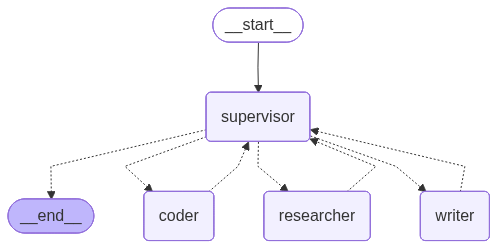

In [7]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())